The DPI of Image is : (95.9866, 95.9866)
The Shape of Image is : (340, 520)


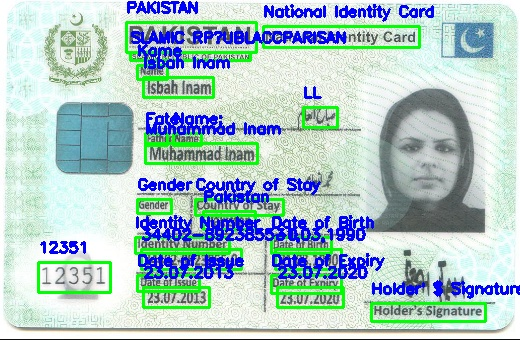

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
import easyocr
import numpy as np
import math
import re
from scipy.spatial import distance
from IPython.display import Image as IPImage  # Rename to avoid conflict

# Initialize the OCR reader
reader = easyocr.Reader(['en'])

# Define the path to your image
image_path = "/kaggle/input/fake-id-card/FAKE_ID_CARD.PNG"

# Open the image using PIL to get DPI
im = Image.open(image_path)

# Read the image using OpenCV
image = cv2.imread(image_path)

# Perform OCR on the image
result = reader.readtext(image_path)

# Display DPI information
dpi = im.info.get('dpi')
print(f"The DPI of Image is : {dpi}")

# Display image shape
shape = image.shape[:-1]
print(f"The Shape of Image is : {shape}")

# Iterate through OCR results and draw bounding boxes on the image
bbs = []
values = []

for (bbox, text, prob) in result:
    values.append(text)
    
    # Unpack the bounding box coordinates
    (tl, tr, br, bl) = bbox
    
    # Convert coordinates to integers
    tl = (int(tl[0]), int(tl[1]))
    tr = (int(tr[0]), int(tr[1]))
    br = (int(br[0]), int(br[1]))
    bl = (int(bl[0]), int(bl[1]))
    
    # Draw bounding box and text on the image
    cv2.rectangle(image, tl, br, (0, 255, 0), 2)
    cv2.putText(image, text, (tl[0], tl[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Save the modified image with bounding boxes
cv2.imwrite('/kaggle/working/output_image.jpg', image)

# Display the saved image using IPython.display.Image
IPImage('/kaggle/working/output_image.jpg')


In [23]:
import easyocr
reader = easyocr.Reader(['en'])
image_path = "/kaggle/input/pak-id/PAK_ID.PNG"
result = reader.readtext(image_path)

In [32]:

# %%
"""
## Normalizing the bounding Boxes 
"""

# %%
def normalize(img,result):
    w,h = img.shape[:-1]
    normalize_bbx = []
    detected_labels = []
    for (bbox, text, prob) in result:
        (tl, tr, br, bl) = bbox
        tl[0],tl[1] = round(tl[0] / h,3),round(tl[1] / w,3)
        tr[0],tr[1] = round(tr[0] / h,3),round(tr[1] / w,3)
        br[0],br[1] = round(br[0] / h,3),round(br[1] / w,3)
        bl[0],bl[1] = round(bl[0] / h,3),round(bl[1] / w,3)
        normalize_bbx.append([tl,tr,br,bl])
        detected_labels.append(text)
    return normalize_bbx,detected_labels

# %%
# CNIC 8
norm_boxes,labels = normalize(image,result)

# %%
normalize_output = list(zip(norm_boxes,labels)) 

# %%
"""
## Measuring Distance 
"""

# %%
def calculate_distance(key,bbx):
    euc_sum = 0
    for val1,val2 in zip(key,bbx):
        euc_sum = euc_sum + distance.euclidean(val1,val2)
        return euc_sum

# %%
"""
## Defining our Static Card Template Boxes  
"""

# %%
# name_key = [[0.272, 0.233], [0.323, 0.233], [0.323, 0.27], [0.272, 0.27]]
name_value = [[0.283, 0.271], [0.415, 0.271], [0.415, 0.325], [0.283, 0.325]]
# father_key = [[0.285, 0.42], [0.388, 0.42], [0.388, 0.457], [0.285, 0.457]]
father_value = [[0.29, 0.456], [0.494, 0.456], [0.494, 0.514], [0.29, 0.514]]
# dob_key = [[0.519, 0.713], [0.631, 0.713], [0.631, 0.756], [0.519, 0.756]]
dob_value = [[0.529, 0.751], [0.648, 0.751], [0.648, 0.803], [0.529, 0.803]]
# doi_key = [[0.274, 0.821], [0.384, 0.821], [0.384, 0.858], [0.274, 0.858]]
doi_value = [[0.285, 0.857], [0.404, 0.857], [0.404, 0.908], [0.285, 0.908]]
# doe_key = [[0.519, 0.821], [0.647, 0.821], [0.647, 0.866], [0.519, 0.866]]
doe_value = [[0.531, 0.859], [0.65, 0.859], [0.65, 0.911], [0.531, 0.911]]

# %%
"""
## Distances Comparison 
"""

# %%
def get_value(key,normalize_output):
    distances = {}
    for bbx,text in normalize_output:
        distances[text] = calculate_distance(key,bbx)
    return distances   

# %%
dict_data = {}
output_dict = {}
output_dict['Name'] = name_value
output_dict['Father Name']  = father_value
output_dict['Date of Birth'] = dob_value
output_dict['Date of Issue'] = doi_value
output_dict['Date of Expiry'] = doe_value

# %%
for key,value in output_dict.items():
    output_dict = get_value(value,normalize_output)
    answer = list(min(output_dict.items(), key=lambda x: x[1]))[0]
    dict_data[key] = answer 



In [28]:
# %%
"""
## Output Dictionary 
"""

# %%
dict_data

# %%
accuracy_df = pd.read_excel("data/accuracy.xlsx")

# %%
accuracy_df

# %%
x = accuracy_df["Accuracy (%)"]
y = accuracy_df["Shape (H,W)"]
z = accuracy_df["DPI"]

# %%
plt.figure(figsize=(30, 6))

plt.subplot(131)
plt.xlabel("Image Shape")
plt.ylabel("Accuracy (%)")
plt.plot(y,sorted(x))

# .lineplot(y,x)
plt.title("Image Shape Vs Accuracy")
plt.subplot(132)
sns.lineplot(z,x)
# plt.plot(z,x)
plt.title("Image DPI Vs Accuracy")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/accuracy.xlsx'

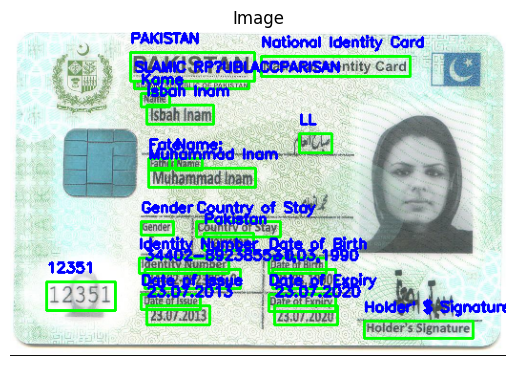

In [33]:
import cv2
from matplotlib import pyplot as plt

# Assuming 'image' is your image array
# Convert BGR image to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.title('Image')
plt.axis('off')  # Hide axes
plt.show()


In [34]:
dict_data

{'Name': 'Isbah Inam',
 'Father Name': 'Muhammad Inam',
 'Date of Birth': '31,03,1990',
 'Date of Issue': '23.07.2013',
 'Date of Expiry': '23.07.2020'}

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
import easyocr
import numpy as np
import math
import re
from scipy.spatial import distance


The DPI of Image is : (95.9866, 95.9866)
The Shape of Image is : (304, 482)


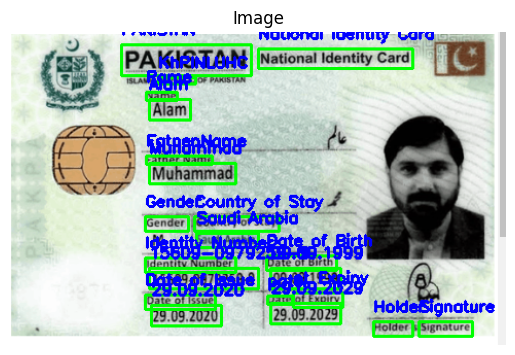

{'Name': 'Alam',
 'Father Name': 'Muhammad',
 'Date of Birth': '09.09.1999',
 'Date of Issue': '29.09.2020',
 'Date of Expiry': '29.09.2029'}

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
import easyocr
import numpy as np
import math
import re
from scipy.spatial import distance
from IPython.display import Image as IPImage  # Rename to avoid conflict

# Initialize the OCR reader
reader = easyocr.Reader(['en'])

# Define the path to your image
image_path = "/kaggle/input/pak-eng-id/PAK_ID_ENG.PNG"

# Open the image using PIL to get DPI
im = Image.open(image_path)

# Read the image using OpenCV
image = cv2.imread(image_path)

# Perform OCR on the image
result = reader.readtext(image_path)

# Display DPI information
dpi = im.info.get('dpi')
print(f"The DPI of Image is : {dpi}")

# Display image shape
shape = image.shape[:-1]
print(f"The Shape of Image is : {shape}")

# Iterate through OCR results and draw bounding boxes on the image
bbs = []
values = []

for (bbox, text, prob) in result:
    values.append(text)
    
    # Unpack the bounding box coordinates
    (tl, tr, br, bl) = bbox
    
    # Convert coordinates to integers
    tl = (int(tl[0]), int(tl[1]))
    tr = (int(tr[0]), int(tr[1]))
    br = (int(br[0]), int(br[1]))
    bl = (int(bl[0]), int(bl[1]))
    
    # Draw bounding box and text on the image
    cv2.rectangle(image, tl, br, (0, 255, 0), 2)
    cv2.putText(image, text, (tl[0], tl[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Save the modified image with bounding boxes
cv2.imwrite('/kaggle/working/output_image.jpg', image)

# Display the saved image using IPython.display.Image
IPImage('/kaggle/working/output_image.jpg')

# %%
"""
## Normalizing the bounding Boxes 
"""

# %%
def normalize(img,result):
    w,h = img.shape[:-1]
    normalize_bbx = []
    detected_labels = []
    for (bbox, text, prob) in result:
        (tl, tr, br, bl) = bbox
        tl[0],tl[1] = round(tl[0] / h,3),round(tl[1] / w,3)
        tr[0],tr[1] = round(tr[0] / h,3),round(tr[1] / w,3)
        br[0],br[1] = round(br[0] / h,3),round(br[1] / w,3)
        bl[0],bl[1] = round(bl[0] / h,3),round(bl[1] / w,3)
        normalize_bbx.append([tl,tr,br,bl])
        detected_labels.append(text)
    return normalize_bbx,detected_labels

# %%
# CNIC 8
norm_boxes,labels = normalize(image,result)

# %%
normalize_output = list(zip(norm_boxes,labels)) 

# %%
"""
## Measuring Distance 
"""

# %%
def calculate_distance(key,bbx):
    euc_sum = 0
    for val1,val2 in zip(key,bbx):
        euc_sum = euc_sum + distance.euclidean(val1,val2)
        return euc_sum

# %%
"""
## Defining our Static Card Template Boxes  
"""

# %%
# name_key = [[0.272, 0.233], [0.323, 0.233], [0.323, 0.27], [0.272, 0.27]]
name_value = [[0.283, 0.271], [0.415, 0.271], [0.415, 0.325], [0.283, 0.325]]
# father_key = [[0.285, 0.42], [0.388, 0.42], [0.388, 0.457], [0.285, 0.457]]
father_value = [[0.29, 0.456], [0.494, 0.456], [0.494, 0.514], [0.29, 0.514]]
# dob_key = [[0.519, 0.713], [0.631, 0.713], [0.631, 0.756], [0.519, 0.756]]
dob_value = [[0.529, 0.751], [0.648, 0.751], [0.648, 0.803], [0.529, 0.803]]
# doi_key = [[0.274, 0.821], [0.384, 0.821], [0.384, 0.858], [0.274, 0.858]]
doi_value = [[0.285, 0.857], [0.404, 0.857], [0.404, 0.908], [0.285, 0.908]]
# doe_key = [[0.519, 0.821], [0.647, 0.821], [0.647, 0.866], [0.519, 0.866]]
doe_value = [[0.531, 0.859], [0.65, 0.859], [0.65, 0.911], [0.531, 0.911]]

# %%
"""
## Distances Comparison 
"""

# %%
def get_value(key,normalize_output):
    distances = {}
    for bbx,text in normalize_output:
        distances[text] = calculate_distance(key,bbx)
    return distances   

# %%
dict_data = {}
output_dict = {}
output_dict['Name'] = name_value
output_dict['Father Name']  = father_value
output_dict['Date of Birth'] = dob_value
output_dict['Date of Issue'] = doi_value
output_dict['Date of Expiry'] = doe_value

# %%
for key,value in output_dict.items():
    output_dict = get_value(value,normalize_output)
    answer = list(min(output_dict.items(), key=lambda x: x[1]))[0]
    dict_data[key] = answer 
import cv2
from matplotlib import pyplot as plt

# Assuming 'image' is your image array
# Convert BGR image to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.title('Image')
plt.axis('off')  # Hide axes
plt.show()

dict_data

The DPI of Image is : (95.9866, 95.9866)
The Shape of Image is : (559, 459)


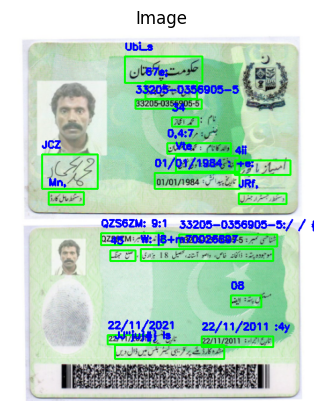

{'Name': '33205-0356905-5',
 'Father Name': 'QZS6ZM: 9:1',
 'Date of Birth': '22/11/2011 :4y',
 'Date of Issue': '22/11/2021',
 'Date of Expiry': '22/11/2011 :4y'}

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from PIL import Image
import easyocr
import numpy as np
import math
import re
from scipy.spatial import distance
from IPython.display import Image as IPImage  # Rename to avoid conflict

# Initialize the OCR reader
reader = easyocr.Reader(['en'])

# Define the path to your image
image_path = "/kaggle/input/pak-id/PAK_ID.PNG"

# Open the image using PIL to get DPI
im = Image.open(image_path)

# Read the image using OpenCV
image = cv2.imread(image_path)

# Perform OCR on the image
result = reader.readtext(image_path)

# Display DPI information
dpi = im.info.get('dpi')
print(f"The DPI of Image is : {dpi}")

# Display image shape
shape = image.shape[:-1]
print(f"The Shape of Image is : {shape}")

# Iterate through OCR results and draw bounding boxes on the image
bbs = []
values = []

for (bbox, text, prob) in result:
    values.append(text)
    
    # Unpack the bounding box coordinates
    (tl, tr, br, bl) = bbox
    
    # Convert coordinates to integers
    tl = (int(tl[0]), int(tl[1]))
    tr = (int(tr[0]), int(tr[1]))
    br = (int(br[0]), int(br[1]))
    bl = (int(bl[0]), int(bl[1]))
    
    # Draw bounding box and text on the image
    cv2.rectangle(image, tl, br, (0, 255, 0), 2)
    cv2.putText(image, text, (tl[0], tl[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Save the modified image with bounding boxes
cv2.imwrite('/kaggle/working/output_image.jpg', image)

# Display the saved image using IPython.display.Image
IPImage('/kaggle/working/output_image.jpg')

# %%
"""
## Normalizing the bounding Boxes 
"""

# %%
def normalize(img,result):
    w,h = img.shape[:-1]
    normalize_bbx = []
    detected_labels = []
    for (bbox, text, prob) in result:
        (tl, tr, br, bl) = bbox
        tl[0],tl[1] = round(tl[0] / h,3),round(tl[1] / w,3)
        tr[0],tr[1] = round(tr[0] / h,3),round(tr[1] / w,3)
        br[0],br[1] = round(br[0] / h,3),round(br[1] / w,3)
        bl[0],bl[1] = round(bl[0] / h,3),round(bl[1] / w,3)
        normalize_bbx.append([tl,tr,br,bl])
        detected_labels.append(text)
    return normalize_bbx,detected_labels

# %%
# CNIC 8
norm_boxes,labels = normalize(image,result)

# %%
normalize_output = list(zip(norm_boxes,labels)) 

# %%
"""
## Measuring Distance 
"""

# %%
def calculate_distance(key,bbx):
    euc_sum = 0
    for val1,val2 in zip(key,bbx):
        euc_sum = euc_sum + distance.euclidean(val1,val2)
        return euc_sum

# %%
"""
## Defining our Static Card Template Boxes  
"""

# %%
# name_key = [[0.272, 0.233], [0.323, 0.233], [0.323, 0.27], [0.272, 0.27]]
name_value = [[0.283, 0.271], [0.415, 0.271], [0.415, 0.325], [0.283, 0.325]]
# father_key = [[0.285, 0.42], [0.388, 0.42], [0.388, 0.457], [0.285, 0.457]]
father_value = [[0.29, 0.456], [0.494, 0.456], [0.494, 0.514], [0.29, 0.514]]
# dob_key = [[0.519, 0.713], [0.631, 0.713], [0.631, 0.756], [0.519, 0.756]]
dob_value = [[0.529, 0.751], [0.648, 0.751], [0.648, 0.803], [0.529, 0.803]]
# doi_key = [[0.274, 0.821], [0.384, 0.821], [0.384, 0.858], [0.274, 0.858]]
doi_value = [[0.285, 0.857], [0.404, 0.857], [0.404, 0.908], [0.285, 0.908]]
# doe_key = [[0.519, 0.821], [0.647, 0.821], [0.647, 0.866], [0.519, 0.866]]
doe_value = [[0.531, 0.859], [0.65, 0.859], [0.65, 0.911], [0.531, 0.911]]

# %%
"""
## Distances Comparison 
"""

# %%
def get_value(key,normalize_output):
    distances = {}
    for bbx,text in normalize_output:
        distances[text] = calculate_distance(key,bbx)
    return distances   

# %%
dict_data = {}
output_dict = {}
output_dict['Name'] = name_value
output_dict['Father Name']  = father_value
output_dict['Date of Birth'] = dob_value
output_dict['Date of Issue'] = doi_value
output_dict['Date of Expiry'] = doe_value

# %%
for key,value in output_dict.items():
    output_dict = get_value(value,normalize_output)
    answer = list(min(output_dict.items(), key=lambda x: x[1]))[0]
    dict_data[key] = answer 
import cv2
from matplotlib import pyplot as plt

# Assuming 'image' is your image array
# Convert BGR image to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.title('Image')
plt.axis('off')  # Hide axes
plt.show()

dict_data